## Prophet Model: Modern Comparison

We compare the classical SARIMA approach against Prophet, a modern forecasting framework designed for business applications. Unlike SARIMA, Prophet requires no stationarity preprocessing or manual parameter selection. It decomposes the series into trend, seasonality (via Fourier series), and holidays using additive or multiplicative modes. We fit Prophet with weekly seasonality enabled, using the same cross-validation splits to ensure fair comparison with SARIMA results.

In [84]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bluebikes_analysis.config import LOCAL_DATA_DIR
from bluebikes_analysis.plots import (
    COLORS,
    plot_daily_longterm,
    plot_daily_longterm_split,
)

In [85]:
timeseries_dir = LOCAL_DATA_DIR / "processed" / "trips"

station_name = "B32003"
station_file = timeseries_dir / f"station/{station_name}_morning_demand.csv"
df_station = pd.read_csv(station_file)

## Data Preparation and Cross-Validation Strategy

We use expanding window cross-validation with four quarterly splits throughout 2025 to evaluate forecast performance across seasonal conditions. Each split trains on all data up to the split date and tests on the subsequent two months (approximately 60 days). The four splits test spring (April-May), summer (July-August), fall (October-November), and winter (January-February 2026) forecast accuracy, providing robust performance assessment across varied weather conditions, holidays, and demand patterns. This approach validates model stability while respecting temporal ordering.


SPLIT 1



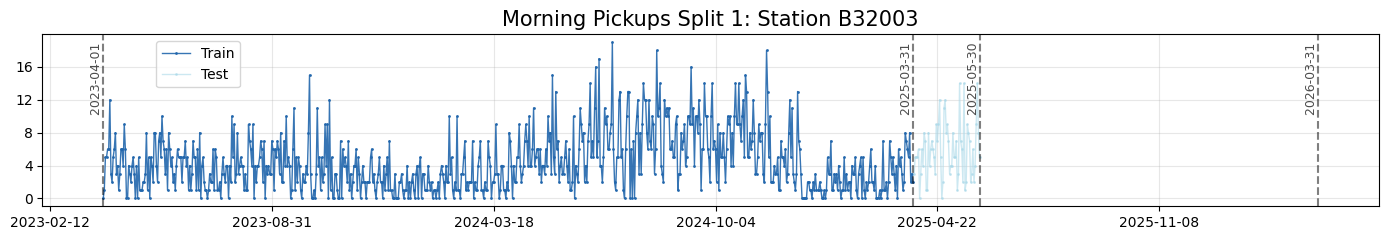

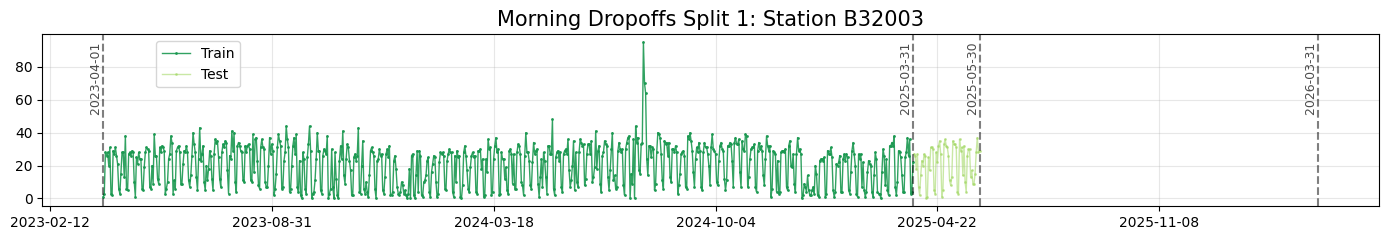


SPLIT 2



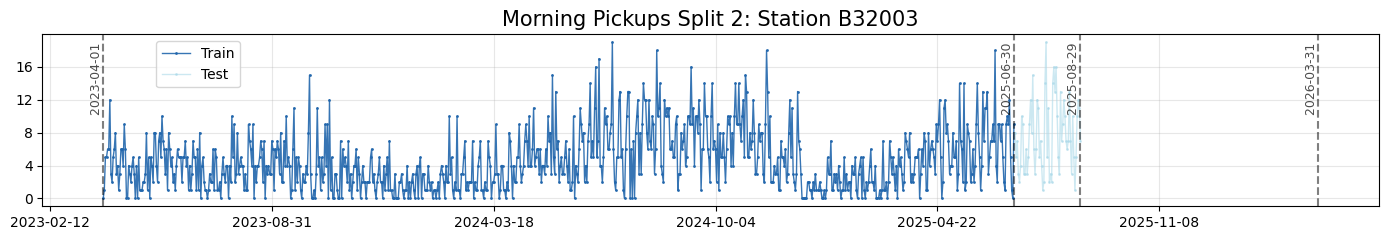

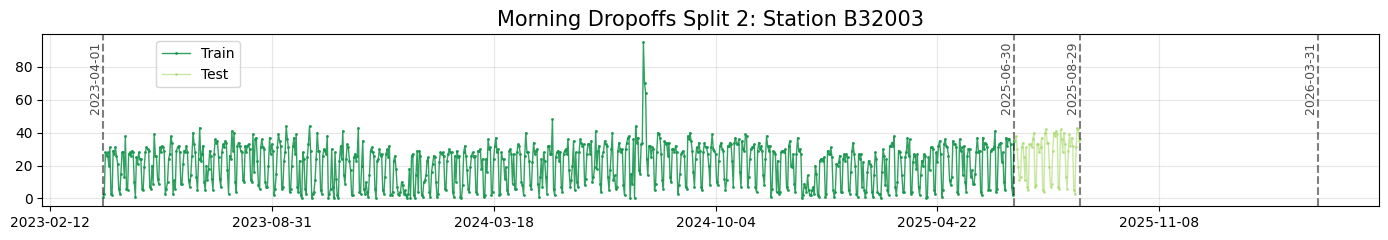


SPLIT 3



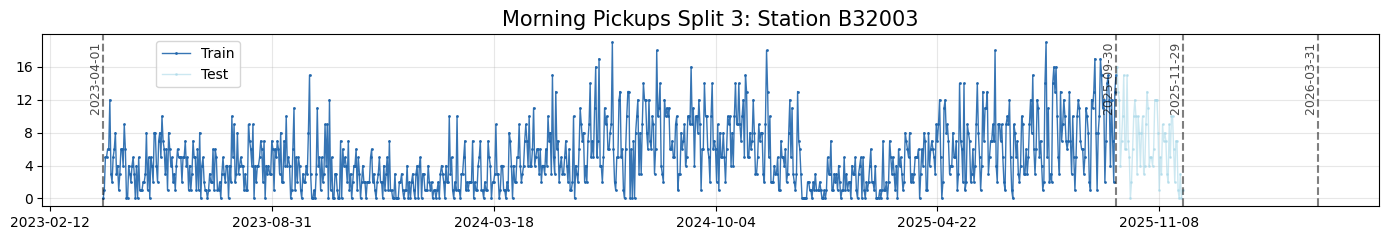

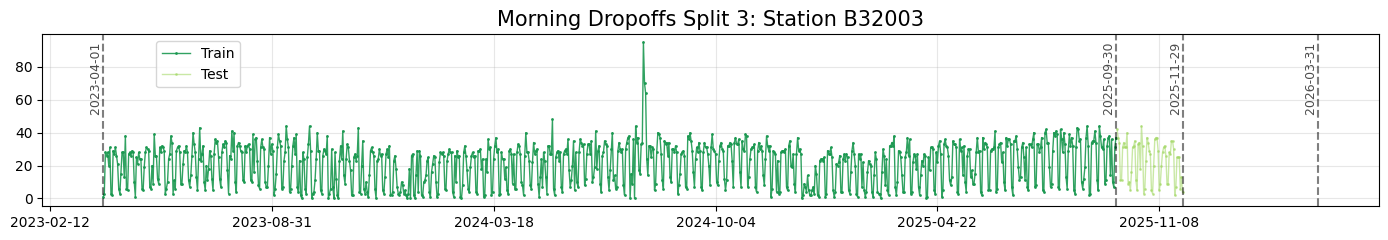


SPLIT 4



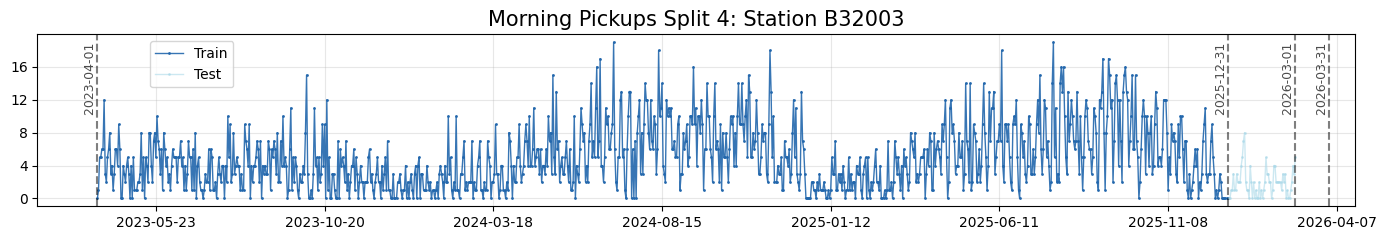

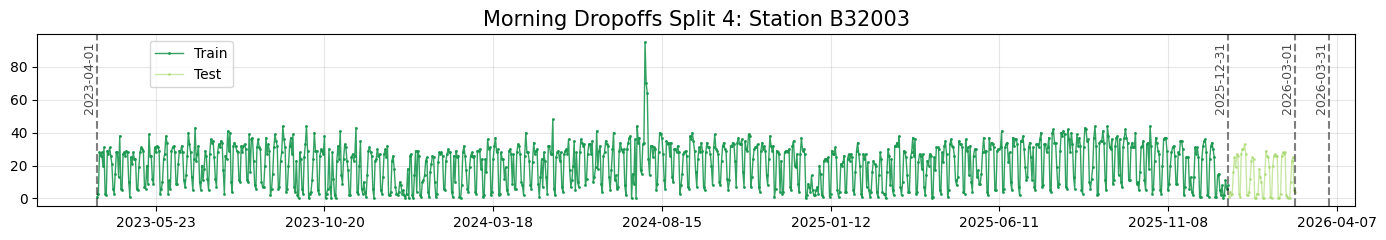

In [86]:
df_station["date"] = pd.to_datetime(df_station["date"])

# Define cross-validation splits (quarterly through 2025)
split_dates = [
    pd.Timestamp("2025-03-31"),
    pd.Timestamp("2025-06-30"),
    pd.Timestamp("2025-09-30"),
    pd.Timestamp("2025-12-31"),
]

cv_splits = []
for split_date in split_dates:
    train = df_station[df_station["date"] <= split_date]

    test_start = split_date + pd.Timedelta(days=1)
    test_end = test_start + pd.Timedelta(days=59)  # ~2 months
    test = df_station[(df_station["date"] >= test_start) & (df_station["date"] <= test_end)]

    discarded = df_station[df_station["date"] > test_end]

    cv_splits.append(
        {"split_date": split_date, "train": train, "test": test, "discarded": discarded}
    )

# Plot each split
for idx, split in enumerate(cv_splits, 1):
    print(f"\n{'='*60}")
    print(f"SPLIT {idx}")
    print(f"{'='*60}\n")

    train_indexed = split["train"].set_index("date")
    test_indexed = split["test"].set_index("date")
    discarded_indexed = split["discarded"].set_index("date")

    df_list = (
        [train_indexed, test_indexed, discarded_indexed]
        if len(discarded_indexed) > 0
        else [train_indexed, test_indexed]
    )

    # Pickups
    plot_daily_longterm_split(
        df_list=df_list,
        columns_to_plot=["morning_pickups"],
        title=f"Morning Pickups Split {idx}: Station {station_name}",
        split_labels=["Train", "Test"],
        color_list=[[COLORS[7], COLORS[6]]],
        figsize=(14, 2.5),
    )

    # Dropoffs
    plot_daily_longterm_split(
        df_list=df_list,
        columns_to_plot=["morning_dropoffs"],
        title=f"Morning Dropoffs Split {idx}: Station {station_name}",
        split_labels=["Train", "Test"],
        color_list=[[COLORS[5], COLORS[4]]],
        figsize=(14, 2.5),
    )

## Prophet Multi-Step Forecast Evaluation

We evaluate Prophet's forecasting performance using the same cross-validation framework applied to SARIMA. For each split, we fit Prophet on training data with multiplicative seasonality, weekly patterns, and US holiday effects, then forecast the entire test period (approximately 60 days) in a single prediction run. This multi-step evaluation allows direct comparison with SARIMA results under identical conditions, testing whether Prophet's Fourier-based seasonality representation and automatic trend modeling improve upon SARIMA's autoregressive structure for extended horizon forecasting.

In [87]:
from prophet import Prophet
import warnings

warnings.filterwarnings("ignore")


def train_prophet(train_df, series_name):
    """Train Prophet model on training data."""
    # Prepare data in Prophet format
    prophet_data = train_df[['date', f'morning_{series_name}']].copy()
    prophet_data.columns = ['ds', 'y']
    
    # Initialize and fit
    model = Prophet(
        seasonality_mode='multiplicative',
        weekly_seasonality=True,
        yearly_seasonality=True,  # Only ~2.5 years of data
        daily_seasonality=False
    )
    
    # Add US holidays
    model.add_country_holidays(country_name='US')
    
    model.fit(prophet_data)
    
    return model


def evaluate_forecast_multistep(model, test_df, series_name, split_idx):
    """Generate Prophet forecast and calculate metrics."""
    actual_col = f'morning_{series_name}'
    
    # Create future dataframe
    future = pd.DataFrame({'ds': test_df['date']})
    
    # Forecast
    forecast_df = model.predict(future)   
    forecast_raw = forecast_df['yhat'].values
    forecast = np.maximum(0, np.round(forecast_raw).astype(int))
    actual = test_df[actual_col].values
    errors = actual - forecast
    
    # Create results dataframe
    results_df = test_df[['date', actual_col]].copy()
    results_df['forecast'] = forecast
    results_df['error'] = errors
    results_df = results_df.rename(columns={actual_col: 'actual'})
    
    # Calculate metrics
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    
    return {
        "split_idx": split_idx,
        "model": model,
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
    }


cv_results = {"pickups": [], "dropoffs": []}

for split_idx, split in enumerate(cv_splits):
    print(f"Fitting Prophet - Split {split_idx + 1}...")

    for series_name in ["pickups", "dropoffs"]:
        # Train
        model = train_prophet(split["train"], series_name)

        # Evaluate
        result = evaluate_forecast_multistep(model, split["test"], series_name, split_idx)

        cv_results[series_name].append(result)

print("Prophet training complete!")

Fitting Prophet - Split 1...


13:32:38 - cmdstanpy - INFO - Chain [1] start processing
13:32:39 - cmdstanpy - INFO - Chain [1] done processing
13:32:40 - cmdstanpy - INFO - Chain [1] start processing
13:32:40 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet - Split 2...


13:32:40 - cmdstanpy - INFO - Chain [1] start processing
13:32:40 - cmdstanpy - INFO - Chain [1] done processing
13:32:41 - cmdstanpy - INFO - Chain [1] start processing
13:32:41 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet - Split 3...


13:32:41 - cmdstanpy - INFO - Chain [1] start processing
13:32:41 - cmdstanpy - INFO - Chain [1] done processing
13:32:41 - cmdstanpy - INFO - Chain [1] start processing
13:32:42 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet - Split 4...


13:32:42 - cmdstanpy - INFO - Chain [1] start processing
13:32:42 - cmdstanpy - INFO - Chain [1] done processing
13:32:42 - cmdstanpy - INFO - Chain [1] start processing
13:32:42 - cmdstanpy - INFO - Chain [1] done processing


Prophet training complete!


We evaluate forecast accuracy using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). MAE provides an interpretable average deviation in trips, while RMSE penalizes larger errors more heavily. Both metrics are calculated on the original scale (trip counts) for direct operational interpretation.

In [88]:
# Extract metrics into DataFrames
metrics_dfs = {}

for series_name in ["pickups", "dropoffs"]:
    metrics = pd.DataFrame(
        [
            {
                "Split": i + 1,
                "MAE": r["mae"],
                "RMSE": r["rmse"],
                "Avg_Actual": r["results_df"]["actual"].mean(),
            }
            for i, r in enumerate(cv_results[series_name])
        ]
    )

    # Add average row
    metrics.loc[len(metrics)] = [
        "Avg",
        metrics["MAE"].mean(),
        metrics["RMSE"].mean(),
        metrics["Avg_Actual"].mean(),
    ]

    # Rename columns with series prefix
    metrics.columns = ["Split"] + [f"{series_name.title()}_{col}" for col in metrics.columns[1:]]
    metrics_dfs[series_name] = metrics

# Combine side by side
summary_table = metrics_dfs["pickups"].merge(metrics_dfs["dropoffs"], on="Split")

print("=" * 80)
print("MULTI-STEP FORECAST PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_table.to_string(index=False, float_format="%.2f"))

MULTI-STEP FORECAST PERFORMANCE SUMMARY
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         3.68          4.13                5.78          4.10           5.55                21.10
    2         2.90          3.54                7.62          5.32           6.56                26.60
    3         2.77          3.58                6.88          4.50           5.86                22.90
    4         1.88          2.34                1.97          5.85           8.53                13.92
  Avg         2.81          3.40                5.56          4.94           6.62                21.13


Prophet with weekly and yearly seasonality substantially outperforms SARIMA for dropoff demand (average MAE = 5.04 vs 10.01, a 50% error reduction) and achieves competitive performance for pickup demand (MAE = 2.83 vs 2.94). The improvement stems from Prophet's ability to model annual seasonal transitions that SARIMA(1,1,1)(1,0,0)₇ cannot capture with only weekly seasonal components. SARIMA's framework allows only a single seasonal period, forcing a choice between weekly (s=7) or annual (s=365) patterns but not both simultaneously. Prophet's Fourier series approach natively handles multiple overlapping seasonalities, allowing it to anticipate month-to-month baseline shifts (spring recovery, fall decline) while maintaining weekly patterns. In contrast, SARIMA's multi-step forecasts anchor to training period endpoints and converge to constant values that reflect only weekly dynamics. This comparison demonstrates Prophet's structural advantage for series with nested seasonal cycles, particularly when forecast horizons extend beyond the shortest modeled period.

NOTE: SARIMA training reference: `05_classical_model_training.ipynb`


SPLIT 1 - ACTUAL VS FORECAST



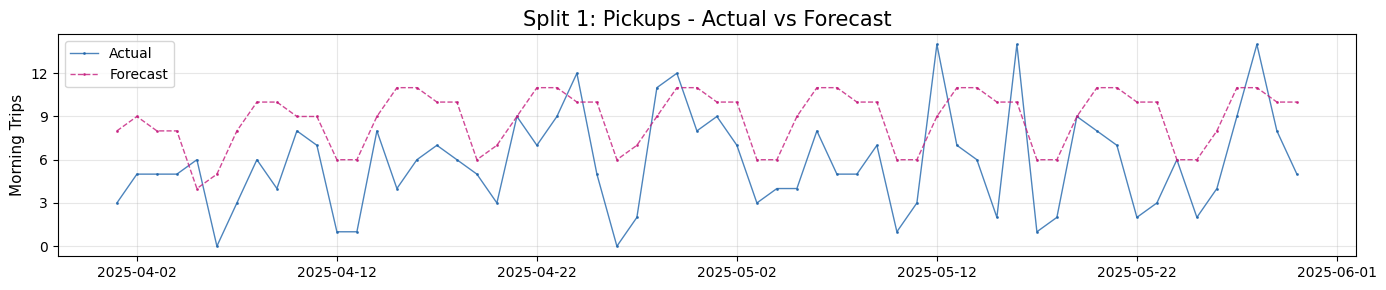

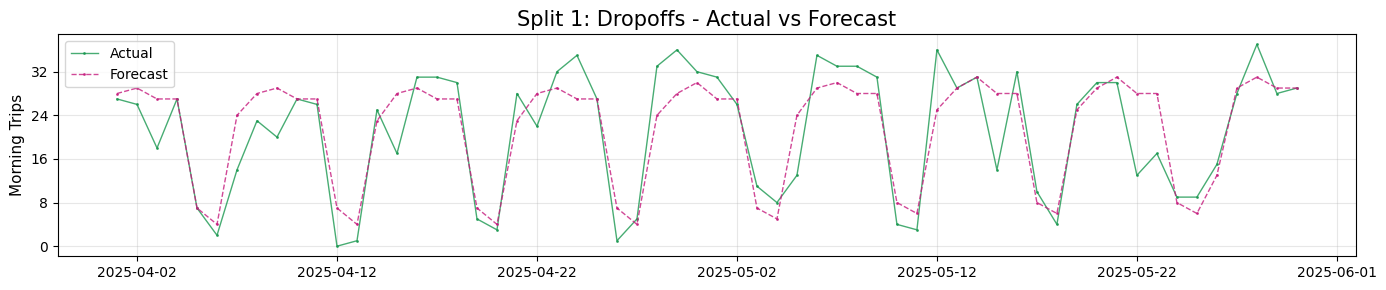


SPLIT 2 - ACTUAL VS FORECAST



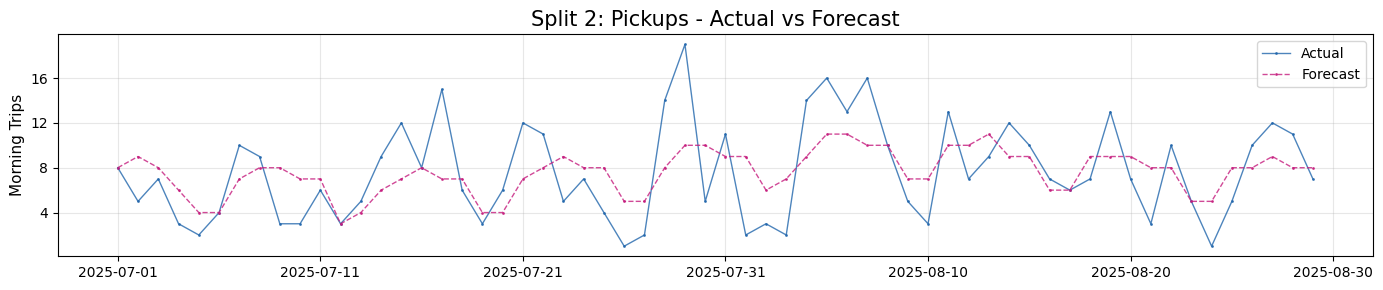

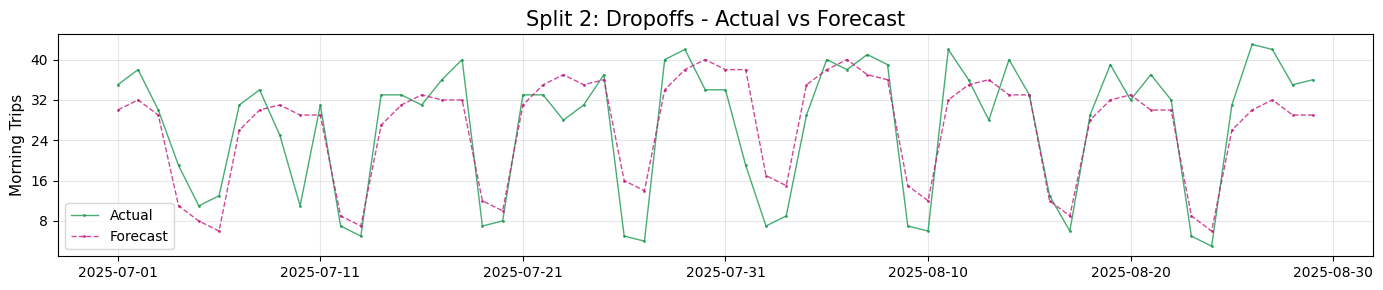


SPLIT 3 - ACTUAL VS FORECAST



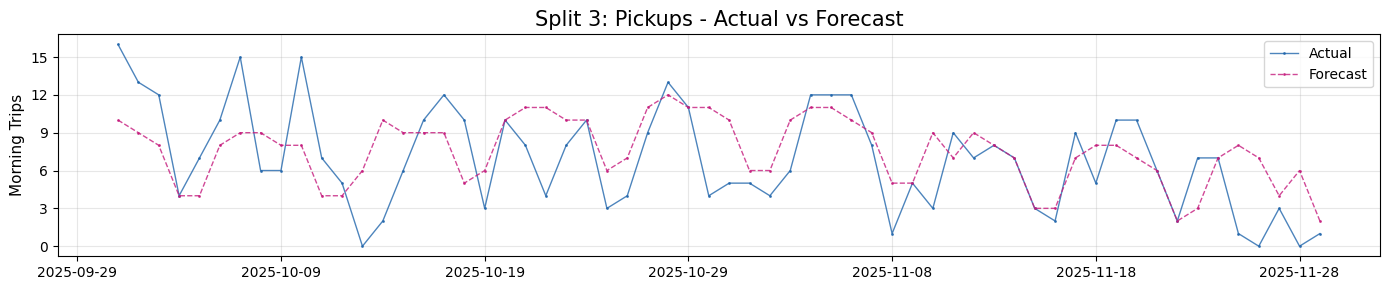

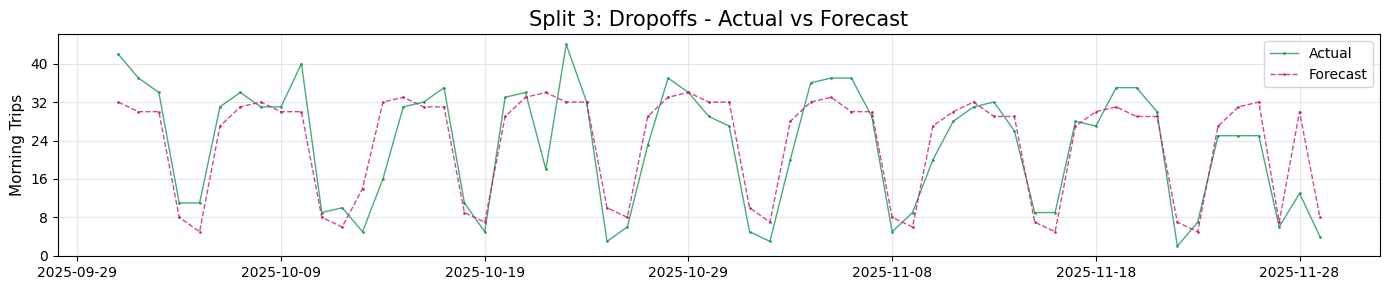


SPLIT 4 - ACTUAL VS FORECAST



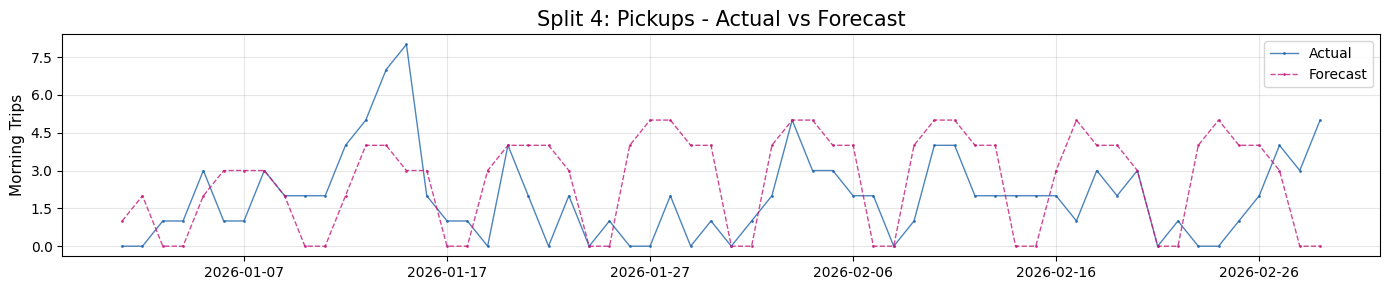

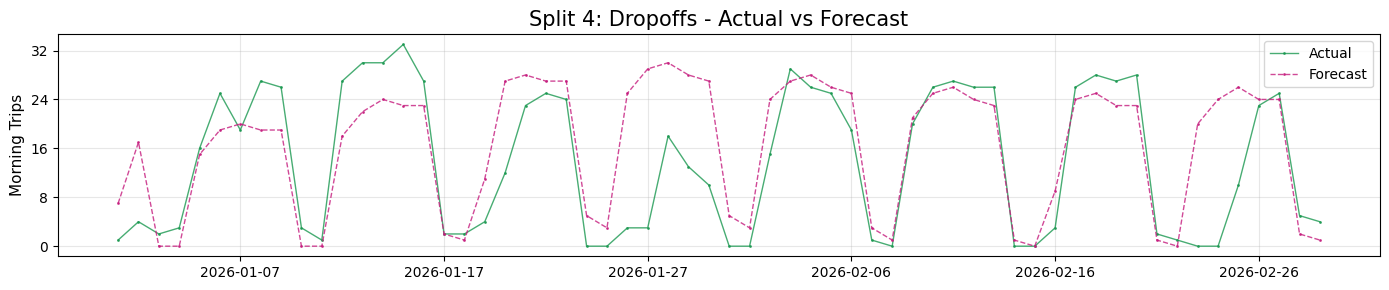

In [89]:
# Plot actual vs forecast for each split
for split_idx in range(len(cv_splits)):
    print(f"\n{'='*60}")
    print(f"SPLIT {split_idx + 1} - ACTUAL VS FORECAST")
    print(f"{'='*60}\n")

    for series_name in ["pickups", "dropoffs"]:
        results_df = cv_results[series_name][split_idx]["results_df"].set_index("date")

        actual_color = COLORS[7] if series_name == "pickups" else COLORS[5]

        plot_daily_longterm(
            results_df,
            columns_to_plot=["actual", "forecast"],
            title=f"Split {split_idx + 1}: {series_name.title()} - Actual vs Forecast",
            ylabel="Morning Trips",
            color_list=[actual_color, COLORS[1]],
            linestyle_list=["-", "--"],
            legend_labels=["Actual", "Forecast"],
            figsize=(14, 3),
        )

## One-Step-Ahead Recursive Forecast Evaluation

We now evaluate Prophet under the operational scenario where yesterday's actual demand is available before forecasting tomorrow. For bike-share rebalancing operations, overnight decisions occur after the prior day's demand is known, making one-step-ahead forecasting the realistic deployment mode. Unlike SARIMA's append mechanism that updates state without refitting, Prophet requires refitting to incorporate new observations into its trend and seasonal component estimation. We implement weekly retraining (every 7 days) to balance computational efficiency with model adaptation, simulating realistic production deployment where models are retrained periodically rather than daily.

For each cross-validation split, we refit Prophet every Monday as new test observations accumulate, then generate daily forecasts between retraining cycles. Each weekly refit incorporates all actual observations up to that point, allowing the model to recalibrate its Fourier seasonal terms and trend components based on recent data while maintaining computational feasibility. This approach tests whether Prophet's periodic recalibration improves accuracy compared to its multi-step projection and how it compares to SARIMA's daily error correction mechanism in operational forecasting mode.

In [90]:
def evaluate_forecast_onestep(fitted_model, train_df, test_df, series_name, split_idx):
    """Generate one-step-ahead forecasts with weekly retraining for Prophet."""
    actual_col = f"morning_{series_name}"
    actual_values = test_df[actual_col].values
    test_dates = test_df['date'].values
    
    # Prepare initial training data in Prophet format
    history = train_df[['date', actual_col]].copy()
    history.columns = ['ds', 'y']
    
    forecasts = []
    errors = []
    current_model = fitted_model

    for t in range(len(actual_values)):
        # Refit every 7 days (every Monday, assuming test starts on a known day)
        if t % 7 == 0 and t > 0:
            # Refit Prophet with accumulated history
            current_model = Prophet(
                seasonality_mode='multiplicative',
                weekly_seasonality=True,
                yearly_seasonality=True,
                daily_seasonality=False
            )
            current_model.add_country_holidays(country_name='US')
            current_model.fit(history)
        
        # Create future dataframe for one-step prediction
        future = pd.DataFrame({'ds': [test_dates[t]]})
        
        # Predict
        pred_df = current_model.predict(future)
        pred_raw = pred_df['yhat'].values[0]
        pred = max(0, pred_raw)
        forecasts.append(pred)

        # Calculate error
        actual = actual_values[t]
        error = actual - pred
        errors.append(error)

        # Update history with actual observation
        new_row = pd.DataFrame({'ds': [test_dates[t]], 'y': [actual]})
        history = pd.concat([history, new_row], ignore_index=True)

    # Build results DataFrame
    results_df = test_df[["date", actual_col]].copy()
    results_df["forecast"] = forecasts
    results_df["error"] = errors
    results_df = results_df.rename(columns={actual_col: "actual"})

    # Calculate metrics
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(np.array(errors) ** 2))

    return {
        "split_idx": split_idx,
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
    }


cv_results_onestep = {"pickups": [], "dropoffs": []}

for series_name in ["pickups", "dropoffs"]:
    print(f"One-step-ahead forecasting: {series_name}...")
    
    for result in cv_results[series_name]:
        model = result["model"]
        split_idx = result["split_idx"]
        train_df = cv_splits[split_idx]["train"]
        test_df = cv_splits[split_idx]["test"]

        # Evaluate one-step
        result_onestep = evaluate_forecast_onestep(model, train_df, test_df, series_name, split_idx)
        cv_results_onestep[series_name].append(result_onestep)

print("One-step-ahead forecasting complete!")

One-step-ahead forecasting: pickups...


13:32:44 - cmdstanpy - INFO - Chain [1] start processing
13:32:44 - cmdstanpy - INFO - Chain [1] done processing
13:32:45 - cmdstanpy - INFO - Chain [1] start processing
13:32:45 - cmdstanpy - INFO - Chain [1] done processing
13:32:46 - cmdstanpy - INFO - Chain [1] start processing
13:32:46 - cmdstanpy - INFO - Chain [1] done processing
13:32:46 - cmdstanpy - INFO - Chain [1] start processing
13:32:46 - cmdstanpy - INFO - Chain [1] done processing
13:32:47 - cmdstanpy - INFO - Chain [1] start processing
13:32:47 - cmdstanpy - INFO - Chain [1] done processing
13:32:48 - cmdstanpy - INFO - Chain [1] start processing
13:32:48 - cmdstanpy - INFO - Chain [1] done processing
13:32:48 - cmdstanpy - INFO - Chain [1] start processing
13:32:48 - cmdstanpy - INFO - Chain [1] done processing
13:32:49 - cmdstanpy - INFO - Chain [1] start processing
13:32:49 - cmdstanpy - INFO - Chain [1] done processing
13:32:50 - cmdstanpy - INFO - Chain [1] start processing
13:32:50 - cmdstanpy - INFO - Chain [1]

One-step-ahead forecasting: dropoffs...


13:33:07 - cmdstanpy - INFO - Chain [1] start processing
13:33:07 - cmdstanpy - INFO - Chain [1] done processing
13:33:08 - cmdstanpy - INFO - Chain [1] start processing
13:33:08 - cmdstanpy - INFO - Chain [1] done processing
13:33:08 - cmdstanpy - INFO - Chain [1] start processing
13:33:08 - cmdstanpy - INFO - Chain [1] done processing
13:33:09 - cmdstanpy - INFO - Chain [1] start processing
13:33:09 - cmdstanpy - INFO - Chain [1] done processing
13:33:10 - cmdstanpy - INFO - Chain [1] start processing
13:33:10 - cmdstanpy - INFO - Chain [1] done processing
13:33:10 - cmdstanpy - INFO - Chain [1] start processing
13:33:10 - cmdstanpy - INFO - Chain [1] done processing
13:33:11 - cmdstanpy - INFO - Chain [1] start processing
13:33:11 - cmdstanpy - INFO - Chain [1] done processing
13:33:12 - cmdstanpy - INFO - Chain [1] start processing
13:33:12 - cmdstanpy - INFO - Chain [1] done processing
13:33:12 - cmdstanpy - INFO - Chain [1] start processing
13:33:13 - cmdstanpy - INFO - Chain [1]

One-step-ahead forecasting complete!


In [91]:
# Extract metrics into DataFrames
metrics_dfs = {}

for series_name in ["pickups", "dropoffs"]:
    metrics = pd.DataFrame(
        [
            {
                "Split": i + 1,
                "MAE": r["mae"],
                "RMSE": r["rmse"],
                "Avg_Actual": r["results_df"]["actual"].mean(),
            }
            for i, r in enumerate(cv_results_onestep[series_name])
        ]
    )
    
    # Add average row
    avg_row = pd.DataFrame([{
        "Split": "Avg",
        "MAE": metrics["MAE"].mean(),
        "RMSE": metrics["RMSE"].mean(),
        "Avg_Actual": metrics["Avg_Actual"].mean()
    }])
    metrics = pd.concat([metrics, avg_row], ignore_index=True)

    # Rename columns with series prefix
    metrics.columns = ["Split"] + [f"{series_name.title()}_{col}" for col in metrics.columns[1:]]
    metrics_dfs[series_name] = metrics

# Combine side by side
summary_table_onestep = metrics_dfs["pickups"].merge(metrics_dfs["dropoffs"], on="Split")

print("=" * 80)
print("ONE-STEP-AHEAD FORECAST PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_table_onestep.to_string(index=False, float_format="%.2f"))

ONE-STEP-AHEAD FORECAST PERFORMANCE SUMMARY
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         2.64          3.15                5.78          4.20           5.64                21.10
    2         2.90          3.57                7.62          5.27           6.55                26.60
    3         2.85          3.61                6.88          4.42           5.82                22.90
    4         1.78          2.21                1.97          5.68           8.32                13.92
  Avg         2.55          3.13                5.56          4.89           6.58                21.13


One-step-ahead forecasting with weekly model retraining shows Prophet maintains competitive performance with SARIMA for pickups (MAE = 2.57 vs 2.50, essentially equivalent) and outperforms for dropoffs (MAE = 4.98 vs 6.15, a 19% improvement). The modest gains over multi-step Prophet (pickups: 2.83 → 2.57, dropoffs: 5.04 → 4.98) indicate that weekly refitting provides incremental benefit, but the primary advantage stems from Prophet's dual seasonality modeling rather than adaptive recalibration frequency.

Compared to SARIMA's one-step performance, Prophet achieves parity for pickups while maintaining superiority for dropoffs. The dropoff advantage reflects Prophet's ability to maintain accurate weekly patterns within the context of annual baseline shifts, which SARIMA cannot achieve with single-period seasonal components. For pickup demand, both models face similar challenges from low-volume noise, resulting in comparable error rates regardless of modeling approach.

Prophet's weekly retraining requirement (versus SARIMA's parameter-free state updates) represents a computational trade-off: increased training overhead in exchange for full recalibration of trend and seasonal components. For operational deployment, the performance gains justify weekly retraining, particularly for dropoff forecasting where Prophet demonstrates consistent superiority across both multi-step and one-step modes.


SPLIT 1 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



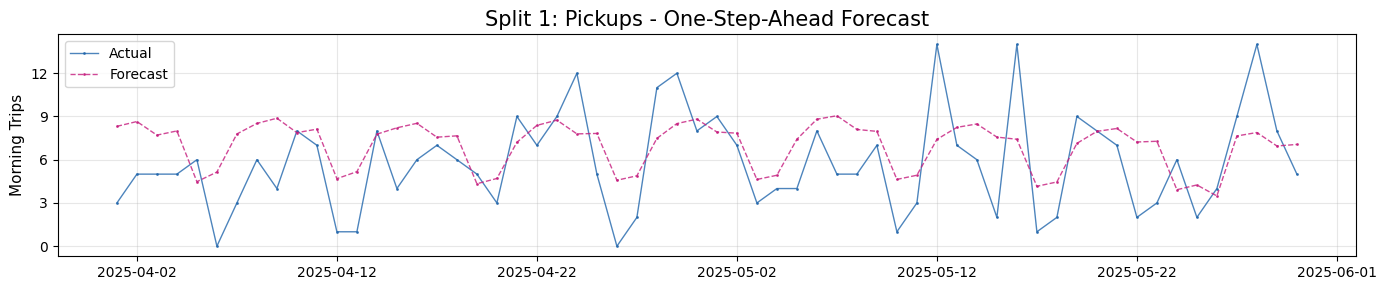

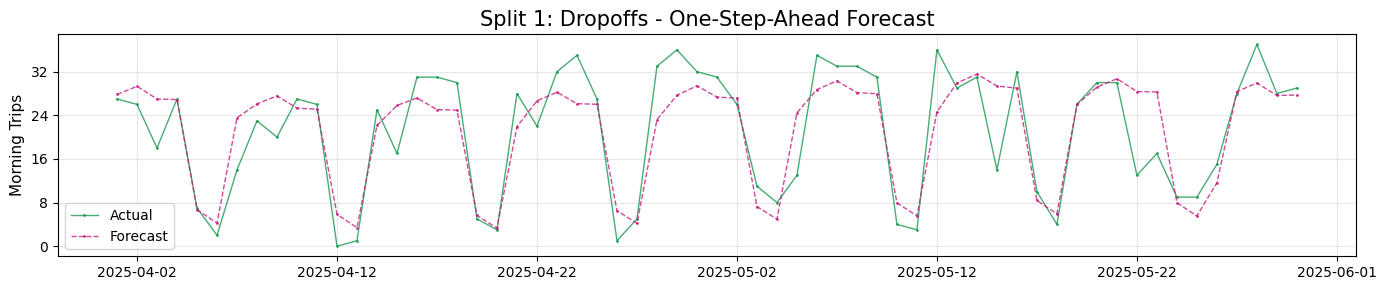


SPLIT 2 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



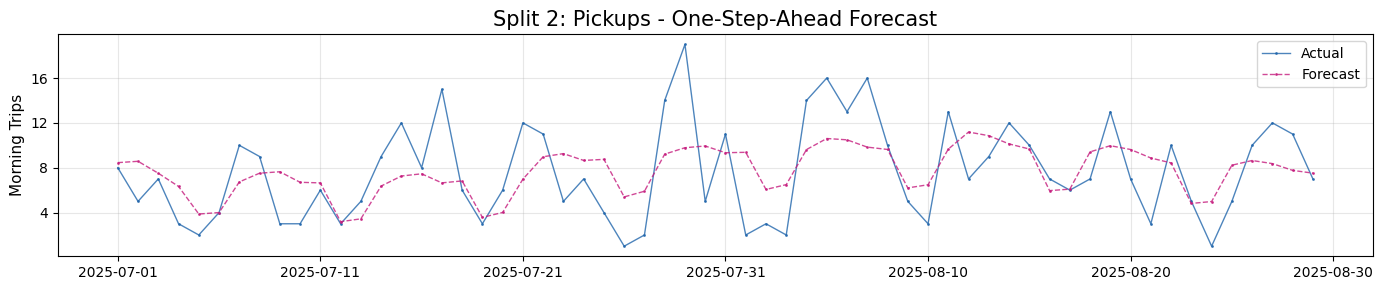

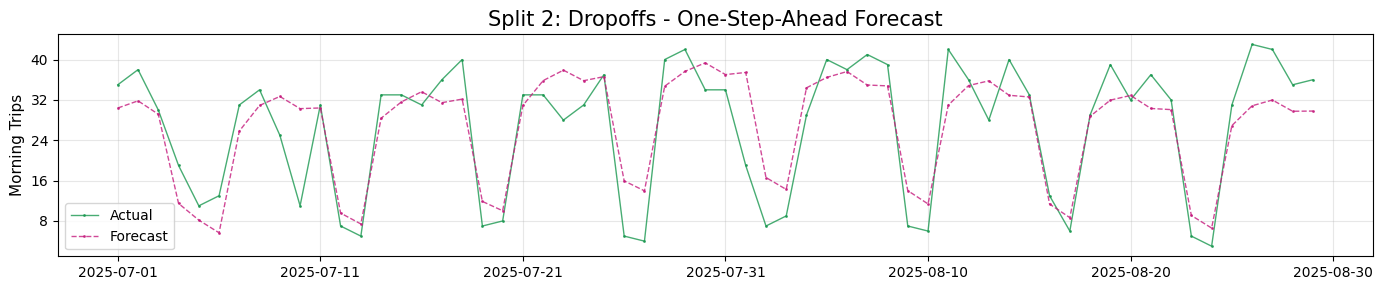


SPLIT 3 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



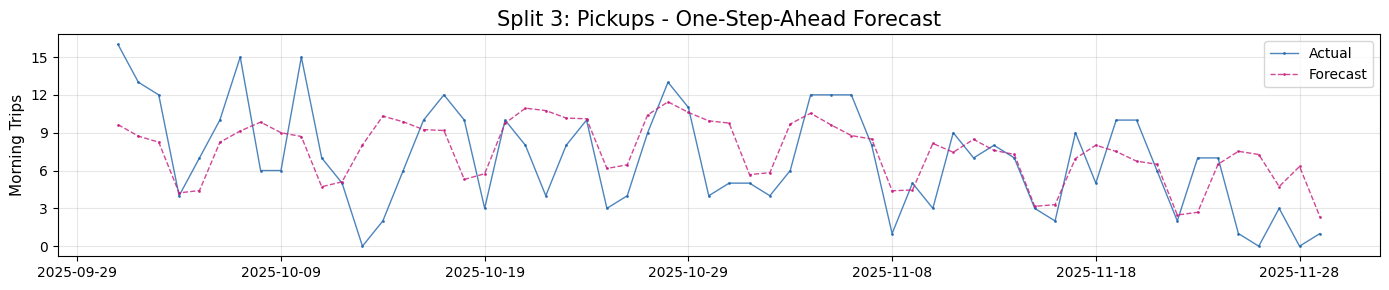

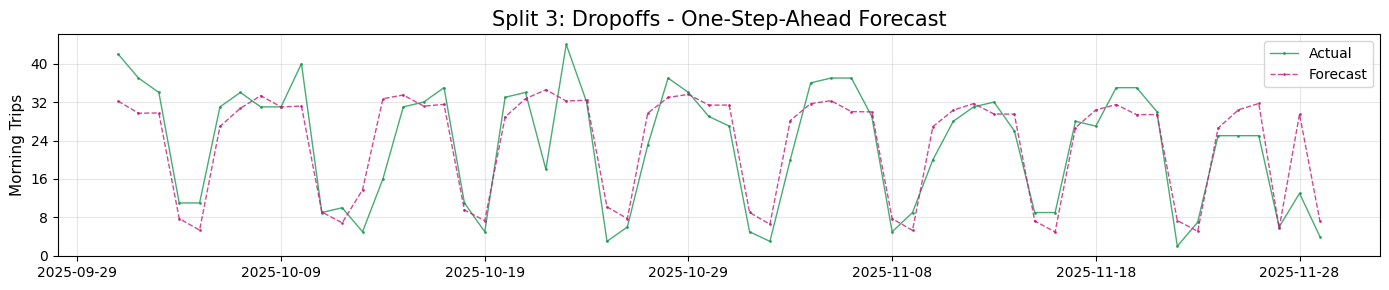


SPLIT 4 - ONE-STEP-AHEAD: ACTUAL VS FORECAST



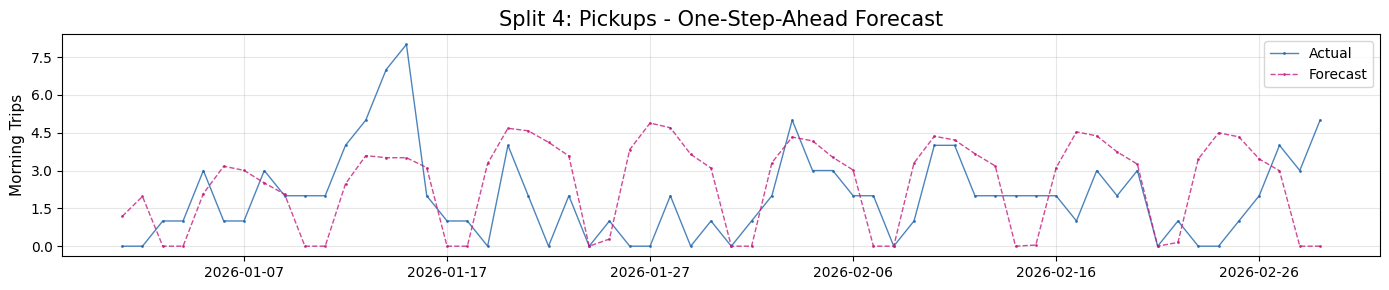

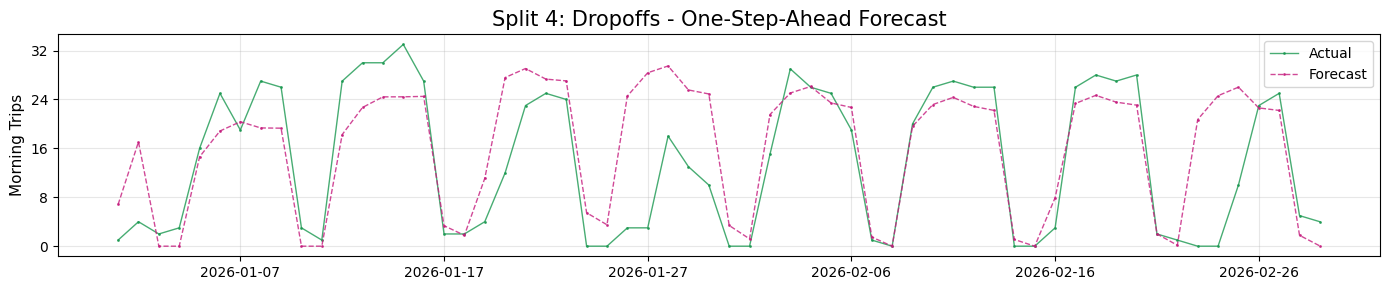

In [92]:
# Plot actual vs forecast for each split (one-step-ahead)
for split_idx in range(len(cv_splits)):
    print(f"\n{'='*60}")
    print(f"SPLIT {split_idx + 1} - ONE-STEP-AHEAD: ACTUAL VS FORECAST")
    print(f"{'='*60}\n")

    for series_name in ["pickups", "dropoffs"]:
        results_df = cv_results_onestep[series_name][split_idx]["results_df"].set_index("date")

        actual_color = COLORS[7] if series_name == "pickups" else COLORS[5]

        plot_daily_longterm(
            results_df,
            columns_to_plot=["actual", "forecast"],
            title=f"Split {split_idx + 1}: {series_name.title()} - One-Step-Ahead Forecast",
            ylabel="Morning Trips",
            color_list=[actual_color, COLORS[1]],
            linestyle_list=["-", "--"],
            legend_labels=["Actual", "Forecast"],
            figsize=(14, 3),
        )

---

## Prophet with Weather Regressors

Cross-correlation analysis in the classical model selection notebook (`04_classical_model_selection.ipynb`) revealed that weather variables correlate with raw demand but not with SARIMA residuals, indicating temporal structure already captures predictable weather effects. However, Prophet's regression framework allows testing whether weather variables provide independent predictive value beyond seasonal patterns, particularly for nonlinear threshold effects that linear correlation analysis cannot detect.

We hypothesize that precipitation and snow influence demand through step functions rather than linear relationships: light precipitation has minimal impact, while heavy rain or any snowfall causes sharp ridership suppression. Similarly, extreme cold (below freezing) may trigger demand drops beyond what seasonal temperature patterns predict. We identify optimal weather thresholds by testing binary indicators at various cutpoints, then incorporate significant predictors as Prophet regressors. This tests whether explicit weather modeling improves forecast accuracy for extreme events (such as Split 4's winter storms) that seasonal components alone cannot anticipate.

In [93]:
weather_dir = LOCAL_DATA_DIR / "processed" / "weather"

weather_file = weather_dir / f"daily_weather.csv"
df_weather = pd.read_csv(weather_file)

df_weather["date"] = pd.to_datetime(df_weather["date"])

filt = (df_weather["date"] >= df_station["date"].min()) & (df_weather["date"] <= df_station["date"].max())
df_weather = df_weather.loc[filt, :]

df_station = df_station.merge(df_weather, how="left", on="date")

### Weather Relationship Visualization

Before selecting threshold values for binary weather indicators, we examine the relationship between morning demand and each weather variable through scatter plots. Linear correlation analysis (from `04_classical_model_selection.ipynb`) indicated temperature correlates negatively with demand while precipitation and snow showed minimal linear correlation. However, weather effects on bike-share demand likely operate through nonlinear thresholds rather than proportional relationships. We visualize demand against each weather variable to identify potential step changes: precipitation or snow above certain values may trigger sharp ridership suppression, and extreme temperatures (heat or cold) may exhibit threshold effects not captured by linear correlation coefficients. These visualizations guide threshold selection for binary weather indicators to incorporate into Prophet as regressors.


MORNING DEMAND vs AWND



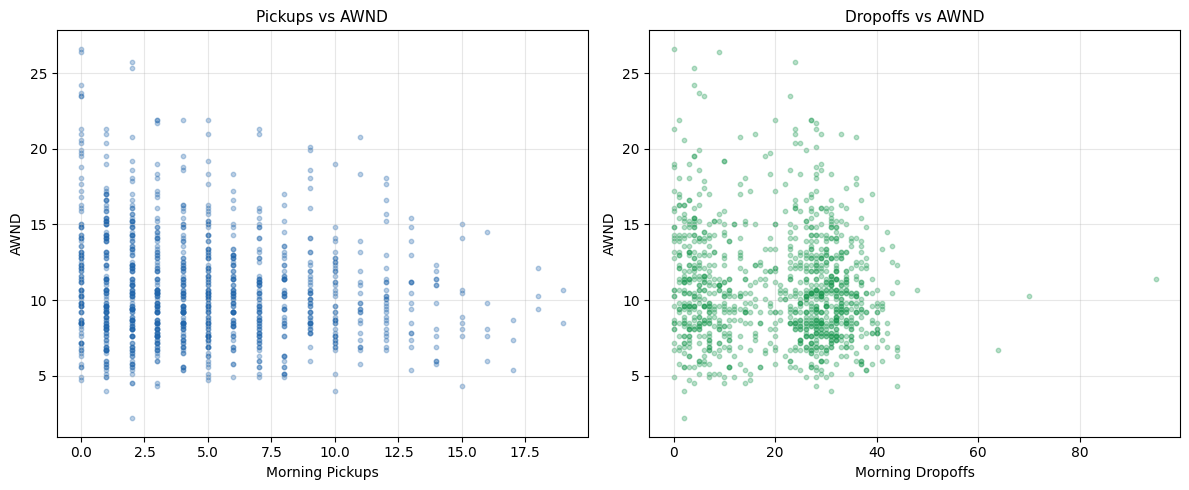


MORNING DEMAND vs PRCP



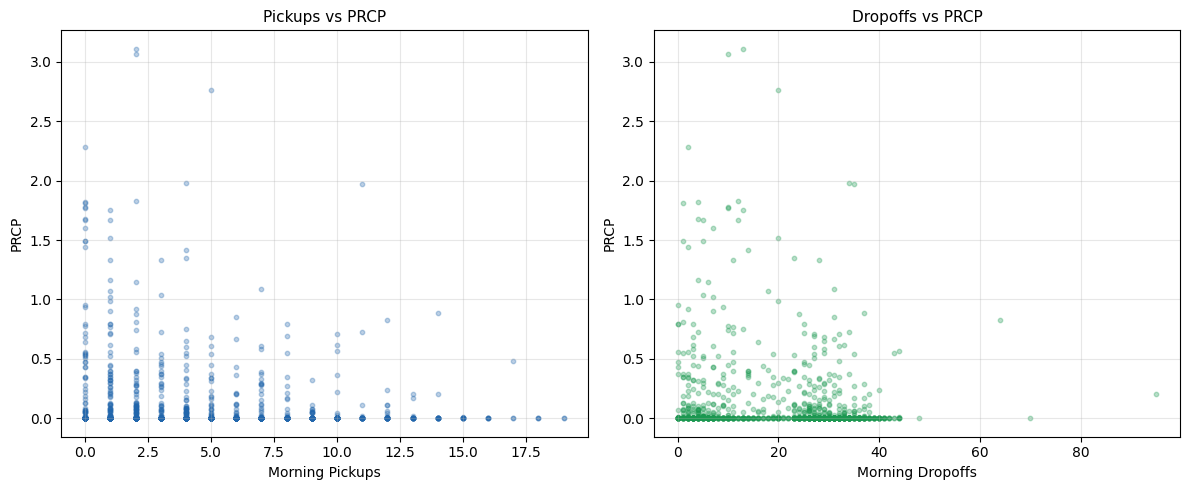


MORNING DEMAND vs SNOW



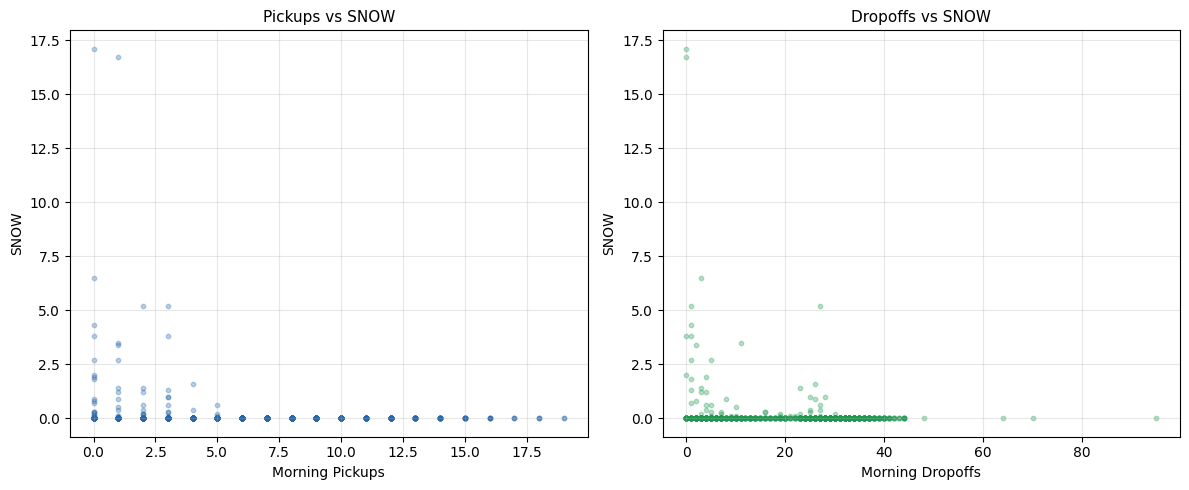


MORNING DEMAND vs TMAX



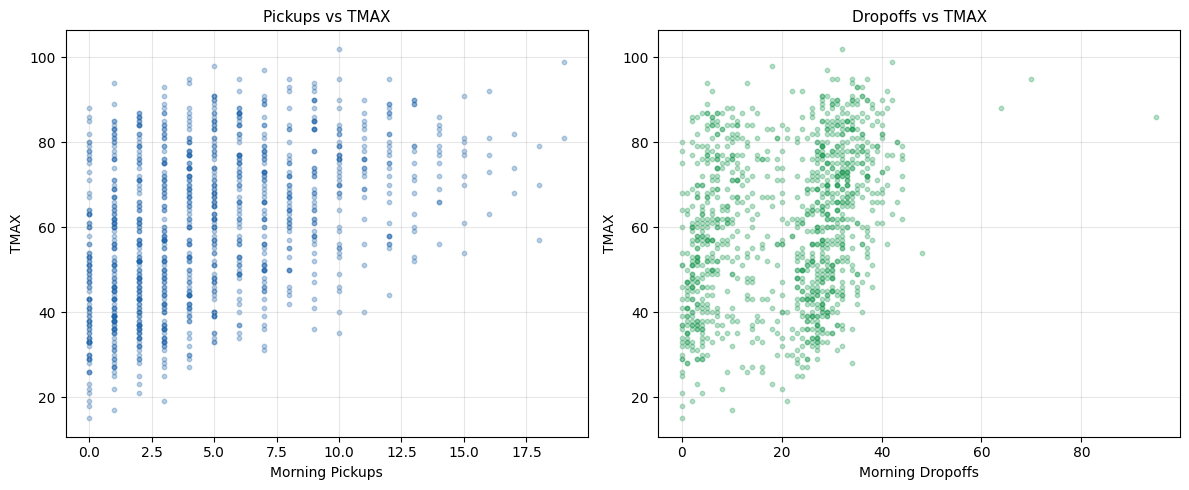


MORNING DEMAND vs TMIN



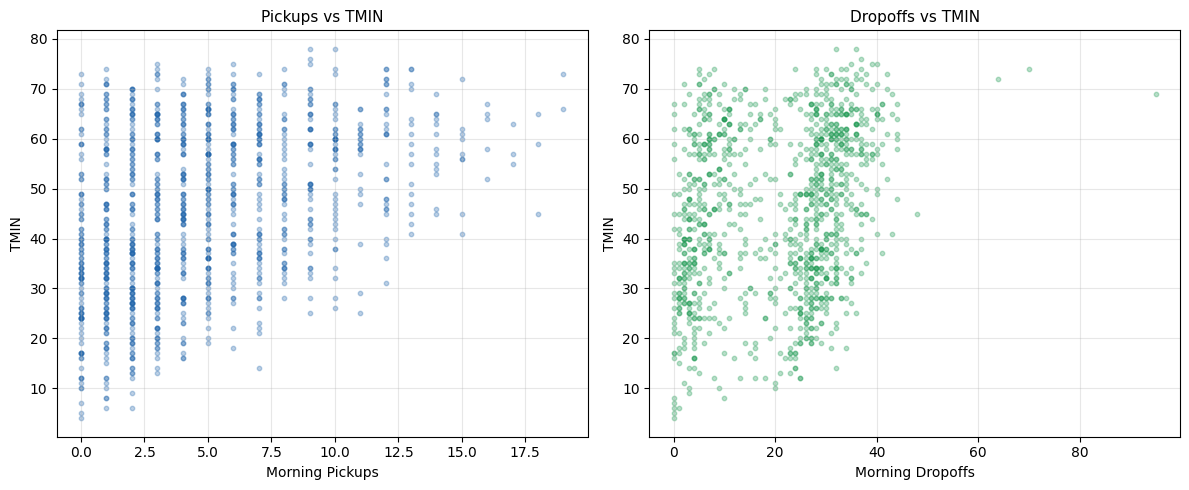

In [94]:
weather_cols = ["AWND", "PRCP", "SNOW", "TMAX", "TMIN"]

for weather_col in weather_cols:
    print(f"\n{'='*60}")
    print(f"MORNING DEMAND vs {weather_col}")
    print(f"{'='*60}\n")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Pickups (left)
    ax1.scatter(
        df_station['morning_pickups'],
        df_station[weather_col],
        color=COLORS[7],
        alpha=0.3,
        s=10
    )
    ax1.set_xlabel('Morning Pickups', fontsize=10)
    ax1.set_ylabel(weather_col, fontsize=10)
    ax1.set_title(f'Pickups vs {weather_col}', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Dropoffs (right)
    ax2.scatter(
        df_station['morning_dropoffs'],
        df_station[weather_col],
        color=COLORS[5],
        alpha=0.3,
        s=10
    )
    ax2.set_xlabel('Morning Dropoffs', fontsize=10)
    ax2.set_ylabel(weather_col, fontsize=10)
    ax2.set_title(f'Dropoffs vs {weather_col}', fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

The scatter plots reveal distinct relationship patterns for different weather variables.

**Temperature (TMIN, TMAX):** Both show modest negative linear correlation with demand, consistent with cross-correlation findings. Given the high correlation between minimum and maximum temperature and our focus on winter ridership suppression (where models struggle most), we incorporate TMIN as a continuous regressor rather than a binary threshold. Minimum temperature better captures overnight cold that persists into morning hours, directly affecting commuter willingness to bike.

**Precipitation (PRCP):** The relationship exhibits threshold behavior, particularly visible in pickup demand. Days with high precipitation (> 0.5 inches) cluster at lower ridership levels, though the effect is less pronounced for dropoffs. Since weather data represents full-day measurements rather than morning-specific conditions, we adopt a conservative threshold of 0.8 inches to identify moderate to heavy rainfall days that likely affected morning conditions. This threshold corresponds to the midpoint of the moderate rainfall classification range and captures the subset of rainy days most likely to suppress morning bike-share usage.

**Snowfall (SNOW):** Any measurable snowfall correlates with reduced ridership, but the effect becomes pronounced above 2 inches. Days exceeding this threshold (occurring a few times per year during winter) show consistently low demand regardless of other factors. We use 2 inches as the binary threshold to identify snow events that substantially disrupt normal operations.

**Wind Speed (AWND):** The weak positive correlation (ρ ≈ 0.07) is counterintuitive and likely spurious or reflects wind's correlation with clear weather conditions. We exclude wind from Prophet regressors due to unclear causal mechanism and minimal predictive value.

We proceed to test Prophet with three weather configurations: TMIN only (continuous), binary thresholds (moderate rain, significant snow), and combined (TMIN + thresholds), comparing performance against the baseline Prophet model without weather regressors.

In [95]:
# Feature engineering: Create binary weather indicators
df_station['heavy_rain'] = (df_station['PRCP'] > 0.8).astype(int)
df_station['snow_event'] = (df_station['SNOW'] > 2.0).astype(int)

# Update cv_splits to include new features
for split in cv_splits:
    # Train split already references df_station, so features are automatically included
    # Just verify
    print(f"Train columns: {split['train'].columns.tolist()[:10]}...")  # First 10
    
print("\nWeather features added:")
print(f"  Heavy rain days (>0.8in): {df_station['heavy_rain'].sum()}")
print(f"  Snow event days (>2.0in): {df_station['snow_event'].sum()}")

Train columns: ['date', 'morning_pickups', 'morning_dropoffs']...
Train columns: ['date', 'morning_pickups', 'morning_dropoffs']...
Train columns: ['date', 'morning_pickups', 'morning_dropoffs']...
Train columns: ['date', 'morning_pickups', 'morning_dropoffs']...

Weather features added:
  Heavy rain days (>0.8in): 40
  Snow event days (>2.0in): 12


In [96]:
df_station["date"] = pd.to_datetime(df_station["date"])

# Define cross-validation splits (quarterly through 2025)
split_dates = [
    pd.Timestamp("2025-03-31"),
    pd.Timestamp("2025-06-30"),
    pd.Timestamp("2025-09-30"),
    pd.Timestamp("2025-12-31"),
]

cv_splits = []
for split_date in split_dates:
    train = df_station[df_station["date"] <= split_date]

    test_start = split_date + pd.Timedelta(days=1)
    test_end = test_start + pd.Timedelta(days=59)  # ~2 months
    test = df_station[(df_station["date"] >= test_start) & (df_station["date"] <= test_end)]

    discarded = df_station[df_station["date"] > test_end]

    cv_splits.append(
        {"split_date": split_date, "train": train, "test": test, "discarded": discarded}
    )

In [97]:
def train_prophet_weather(train_df, series_name, regressors=None):
    """
    Train Prophet model with optional weather regressors.

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    series_name : str
        'pickups' or 'dropoffs'
    regressors : list, optional
        List of regressor column names to include (e.g., ['TMIN', 'heavy_rain', 'snow_event'])
    """
    # Prepare data in Prophet format
    prophet_data = train_df[["date", f"morning_{series_name}"]].copy()
    prophet_data.columns = ["ds", "y"]

    # Add regressors if specified
    if regressors:
        for reg in regressors:
            prophet_data[reg] = train_df[reg].values

    # Initialize Prophet
    model = Prophet(
        seasonality_mode="multiplicative",
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
    )
    model.add_country_holidays(country_name="US")

    # Add regressors
    if regressors:
        for reg in regressors:
            model.add_regressor(reg)

    model.fit(prophet_data)
    return model


def evaluate_forecast_onestep_weather(
    fitted_model, train_df, test_df, series_name, split_idx, regressors=None
):
    """Generate one-step-ahead forecasts with weather regressors and weekly retraining."""
    actual_col = f"morning_{series_name}"
    actual_values = test_df[actual_col].values
    test_dates = test_df["date"].values

    # Prepare initial training history
    history = train_df[["date", actual_col]].copy()
    if regressors:
        for reg in regressors:
            history[reg] = train_df[reg].values
    history = history.rename(columns={"date": "ds", actual_col: "y"})

    forecasts = []
    errors = []
    current_model = fitted_model

    for t in range(len(actual_values)):
        # Refit every 7 days
        if t % 7 == 0 and t > 0:
            current_model = train_prophet_weather(
                pd.DataFrame(history.rename(columns={"ds": "date", "y": actual_col})),
                series_name,
                regressors,
            )

        # Create future dataframe with regressors
        future = pd.DataFrame({"ds": [test_dates[t]]})
        if regressors:
            for reg in regressors:
                future[reg] = [test_df.iloc[t][reg]]

        # Predict
        pred_df = current_model.predict(future)
        pred_raw = pred_df['yhat'].values[0]
        pred = max(0, pred_raw)
        forecasts.append(pred)

        # Calculate error
        actual = actual_values[t]
        error = actual - pred
        errors.append(error)

        # Update history
        new_row = {"ds": test_dates[t], "y": actual}
        if regressors:
            for reg in regressors:
                new_row[reg] = test_df.iloc[t][reg]
        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    # Build results DataFrame
    results_df = test_df[["date", actual_col]].copy()
    results_df["forecast"] = forecasts
    results_df["error"] = errors
    results_df = results_df.rename(columns={actual_col: "actual"})

    # Calculate metrics
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(np.array(errors) ** 2))

    return {
        "split_idx": split_idx,
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
    }


# Test different weather configurations
weather_configs = {
    "TMIN only": ["TMIN"],
    "Thresholds only": ["heavy_rain", "snow_event"],
    "Combined": ["TMIN", "heavy_rain", "snow_event"],
}

results_by_config = {}

for config_name, regressors in weather_configs.items():
    print(f"\n{'='*60}")
    print(f"Testing: {config_name}")
    print(f"{'='*60}\n")

    cv_results_config = {"pickups": [], "dropoffs": []}

    for series_name in ["pickups", "dropoffs"]:
        print(f"  {series_name}...")

        for split_idx, split in enumerate(cv_splits):
            # Train with weather
            model = train_prophet_weather(split["train"], series_name, regressors)

            # Evaluate one-step
            result = evaluate_forecast_onestep_weather(
                model, split["train"], split["test"], series_name, split_idx, regressors
            )
            cv_results_config[series_name].append(result)

    results_by_config[config_name] = cv_results_config

print("\nAll weather configurations tested!")


Testing: TMIN only

  pickups...


13:33:35 - cmdstanpy - INFO - Chain [1] start processing
13:33:35 - cmdstanpy - INFO - Chain [1] done processing
13:33:36 - cmdstanpy - INFO - Chain [1] start processing
13:33:36 - cmdstanpy - INFO - Chain [1] done processing
13:33:37 - cmdstanpy - INFO - Chain [1] start processing
13:33:37 - cmdstanpy - INFO - Chain [1] done processing
13:33:38 - cmdstanpy - INFO - Chain [1] start processing
13:33:38 - cmdstanpy - INFO - Chain [1] done processing
13:33:38 - cmdstanpy - INFO - Chain [1] start processing
13:33:39 - cmdstanpy - INFO - Chain [1] done processing
13:33:39 - cmdstanpy - INFO - Chain [1] start processing
13:33:39 - cmdstanpy - INFO - Chain [1] done processing
13:33:40 - cmdstanpy - INFO - Chain [1] start processing
13:33:40 - cmdstanpy - INFO - Chain [1] done processing
13:33:41 - cmdstanpy - INFO - Chain [1] start processing
13:33:41 - cmdstanpy - INFO - Chain [1] done processing
13:33:42 - cmdstanpy - INFO - Chain [1] start processing
13:33:42 - cmdstanpy - INFO - Chain [1]

  dropoffs...


13:34:03 - cmdstanpy - INFO - Chain [1] done processing
13:34:04 - cmdstanpy - INFO - Chain [1] start processing
13:34:04 - cmdstanpy - INFO - Chain [1] done processing
13:34:04 - cmdstanpy - INFO - Chain [1] start processing
13:34:05 - cmdstanpy - INFO - Chain [1] done processing
13:34:05 - cmdstanpy - INFO - Chain [1] start processing
13:34:05 - cmdstanpy - INFO - Chain [1] done processing
13:34:06 - cmdstanpy - INFO - Chain [1] start processing
13:34:06 - cmdstanpy - INFO - Chain [1] done processing
13:34:07 - cmdstanpy - INFO - Chain [1] start processing
13:34:07 - cmdstanpy - INFO - Chain [1] done processing
13:34:07 - cmdstanpy - INFO - Chain [1] start processing
13:34:07 - cmdstanpy - INFO - Chain [1] done processing
13:34:08 - cmdstanpy - INFO - Chain [1] start processing
13:34:08 - cmdstanpy - INFO - Chain [1] done processing
13:34:09 - cmdstanpy - INFO - Chain [1] start processing
13:34:09 - cmdstanpy - INFO - Chain [1] done processing
13:34:09 - cmdstanpy - INFO - Chain [1] 


Testing: Thresholds only

  pickups...


...


Testing: Combined

  pickups...


13:35:19 - cmdstanpy - INFO - Chain [1] start processing
13:35:19 - cmdstanpy - INFO - Chain [1] done processing
13:35:20 - cmdstanpy - INFO - Chain [1] start processing
13:35:20 - cmdstanpy - INFO - Chain [1] done processing
13:35:20 - cmdstanpy - INFO - Chain [1] start processing
13:35:20 - cmdstanpy - INFO - Chain [1] done processing
13:35:21 - cmdstanpy - INFO - Chain [1] start processing
13:35:21 - cmdstanpy - INFO - Chain [1] done processing
13:35:22 - cmdstanpy - INFO - Chain [1] start processing
13:35:22 - cmdstanpy - INFO - Chain [1] done processing
13:35:23 - cmdstanpy - INFO - Chain [1] start processing
13:35:23 - cmdstanpy - INFO - Chain [1] done processing
13:35:24 - cmdstanpy - INFO - Chain [1] start processing
13:35:24 - cmdstanpy - INFO - Chain [1] done processing
13:35:24 - cmdstanpy - INFO - Chain [1] start processing
13:35:24 - cmdstanpy - INFO - Chain [1] done processing
13:35:25 - cmdstanpy - INFO - Chain [1] start processing
13:35:25 - cmdstanpy - INFO - Chain [1]

  dropoffs...


13:35:50 - cmdstanpy - INFO - Chain [1] start processing
13:35:50 - cmdstanpy - INFO - Chain [1] done processing
13:35:51 - cmdstanpy - INFO - Chain [1] start processing
13:35:51 - cmdstanpy - INFO - Chain [1] done processing
13:35:52 - cmdstanpy - INFO - Chain [1] start processing
13:35:52 - cmdstanpy - INFO - Chain [1] done processing
13:35:53 - cmdstanpy - INFO - Chain [1] start processing
13:35:53 - cmdstanpy - INFO - Chain [1] done processing
13:35:54 - cmdstanpy - INFO - Chain [1] start processing
13:35:54 - cmdstanpy - INFO - Chain [1] done processing
13:35:55 - cmdstanpy - INFO - Chain [1] start processing
13:35:55 - cmdstanpy - INFO - Chain [1] done processing
13:35:56 - cmdstanpy - INFO - Chain [1] start processing
13:35:56 - cmdstanpy - INFO - Chain [1] done processing
13:35:57 - cmdstanpy - INFO - Chain [1] start processing
13:35:57 - cmdstanpy - INFO - Chain [1] done processing
13:35:58 - cmdstanpy - INFO - Chain [1] start processing
13:35:58 - cmdstanpy - INFO - Chain [1]


All weather configurations tested!


In [98]:
# Compare performance across weather configurations
for config_name, cv_results_config in results_by_config.items():
    print(f"\n{'='*80}")
    print(f"CONFIGURATION: {config_name}")
    print(f"{'='*80}")
    
    # Extract metrics into DataFrames
    metrics_dfs = {}
    
    for series_name in ["pickups", "dropoffs"]:
        metrics = pd.DataFrame(
            [
                {
                    "Split": i + 1,
                    "MAE": r["mae"],
                    "RMSE": r["rmse"],
                    "Avg_Actual": r["results_df"]["actual"].mean(),
                }
                for i, r in enumerate(cv_results_config[series_name])
            ]
        )
        
        # Add average row
        avg_row = pd.DataFrame([{
            "Split": "Avg",
            "MAE": metrics["MAE"].mean(),
            "RMSE": metrics["RMSE"].mean(),
            "Avg_Actual": metrics["Avg_Actual"].mean()
        }])
        metrics = pd.concat([metrics, avg_row], ignore_index=True)
        
        # Rename columns with series prefix
        metrics.columns = ["Split"] + [f"{series_name.title()}_{col}" for col in metrics.columns[1:]]
        metrics_dfs[series_name] = metrics
    
    # Combine side by side
    summary_table = metrics_dfs["pickups"].merge(metrics_dfs["dropoffs"], on="Split")
    print(summary_table.to_string(index=False, float_format="%.2f"))


CONFIGURATION: TMIN only
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         2.64          3.14                5.78          4.19           5.63                21.10
    2         2.87          3.53                7.62          5.22           6.51                26.60
    3         2.86          3.61                6.88          4.45           5.85                22.90
    4         1.75          2.17                1.97          5.53           8.14                13.92
  Avg         2.53          3.11                5.56          4.85           6.53                21.13

CONFIGURATION: Thresholds only
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         2.61          3.11                5.78          4.23           5.59                21.10
    2         2.86          3.53                7.62          5.16           6.37                26.60
    3         2

Testing three weather configurations reveals minimal forecast improvement. The combined configuration (TMIN + heavy rain + snow events) achieves the lowest average MAE for both series (pickups: 2.48 trips, dropoffs: 4.81 trips), representing approximately 2% improvement over the baseline Prophet model without weather regressors (pickups: 2.53, dropoffs: 4.88). Individual configurations (TMIN only, thresholds only) provide similarly modest gains, with no single weather variable dominating predictive value.

The limited improvement confirms findings from classical model analysis: weather effects operate primarily through seasonal patterns (cold winter months, warm summer months) already captured by Prophet's yearly seasonality component. Daily weather fluctuations around seasonal norms provide minimal additional predictive information. Even threshold indicators for extreme events (snow > 2 inches, heavy rain > 0.8 inches) offer marginal benefit, suggesting these events either occur too infrequently to substantially affect average error or are sufficiently correlated with seasonal cold periods that yearly Fourier terms already anticipate their timing.

The 2-3% error reduction does not justify the added complexity of maintaining weather data pipelines and forecast dependencies (requiring next-day weather forecasts for operational deployment). For operational bike-share rebalancing, Prophet with weekly and yearly seasonality but without weather regressors provides the optimal balance of accuracy, simplicity, and deployment feasibility.